# Import libraries

In [4]:
# Data manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train-test split
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, RobustScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import(
accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay, PrecisionRecallDisplay
)

# Load the dataset

In [5]:
df = pd.read_csv('../datasets/titanic.csv')

In [6]:
# Dataset description
df.info()
df.describe()
df.head()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# Feature selection

In [7]:
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
target = 'Survived'

X = df[features]
y = df[target]

# Train-test split

In [8]:
# 70% training and 30% testing split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Build the processing pipeline

In [68]:
# Numerical and categorical features
numerical_features = ['Age', 'SibSp', 'Parch', 'Fare']
categorical_features = ['Pclass', 'Sex', 'Embarked']

# Numerical and categorical transformers
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])  

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, numerical_features),
    ('cat', categorical_transformer, categorical_features)
])

# Create the models

In [69]:
# Models creation
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Support Vector Machine': SVC(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

# Train models

In [70]:
# Model training 
results = []
for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    results.append({
        'model': model_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1_score': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_pred)
    })

results[0]['accuracy']

0.8059701492537313

# Create the comparison table

In [74]:
comparison_df = pd.DataFrame(results, columns=['model', 'accuracy', 'precision', 'recall', 'f1_score', 'roc_auc'])
comparison_df.sort_values(by='accuracy', ascending=False, inplace=True)
comparison_df.info()
comparison_df.head()

<class 'pandas.DataFrame'>
Index: 6 entries, 4 to 2
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   model      6 non-null      str    
 1   accuracy   6 non-null      float64
 2   precision  6 non-null      float64
 3   recall     6 non-null      float64
 4   f1_score   6 non-null      float64
 5   roc_auc    6 non-null      float64
dtypes: float64(5), str(1)
memory usage: 336.0 bytes


,model,accuracy,precision,recall,f1_score,roc_auc
4,Support Vector Machine,0.824627,0.840426,0.711712,0.770732,0.808085
0,Logistic Regression,0.805970,0.797980,0.711712,0.752381,0.792162
1,K-Nearest Neighbors,0.802239,0.815217,0.675676,0.738916,0.783698
3,Random Forest,0.787313,0.770000,0.693694,0.729858,0.773598
5,XGBoost,0.772388,0.735849,0.702703,0.718894,0.762179


# Visualize model accuracy

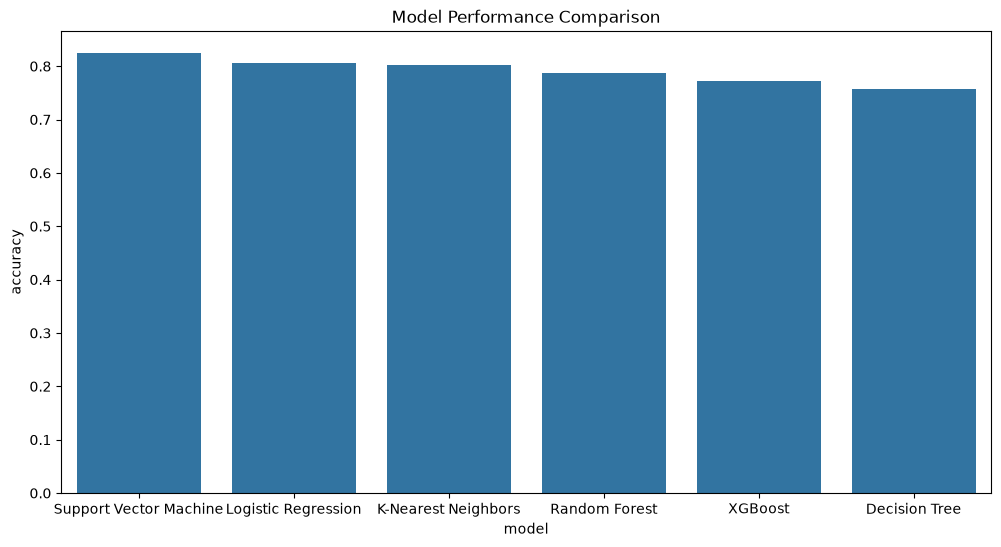

In [76]:
# Visualization of model performance
plt.figure(figsize=(12, 6))
sns.barplot(data=comparison_df, x='model', y='accuracy')
plt.title('Model Performance Comparison')
plt.show()

# Confusion matrix

In [77]:
# Confusion matrix for the best model
best_model_name = comparison_df.iloc[0]['model']
best_model = models[best_model_name]
best_model

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


<Axes: >

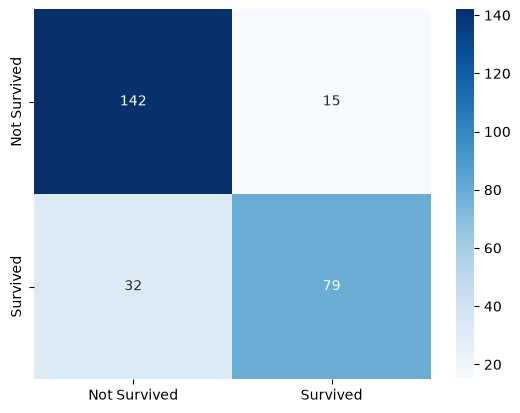

In [78]:
# Pipeline for the best model
best_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', best_model)  
])

best_pipeline.fit(X_train, y_train)

predictions = best_pipeline.predict(X_test)

confusion_mtx = confusion_matrix(y_test, predictions)

sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Survived', 'Survived'], yticklabels=['Not Survived', 'Survived'])

# Classification report

In [79]:
classification_rpt = classification_report(y_test, predictions, target_names=['Not Survived', 'Survived'])
classification_rpt

'              precision    recall  f1-score   support\n\nNot Survived       0.82      0.90      0.86       157\n    Survived       0.84      0.71      0.77       111\n\n    accuracy                           0.82       268\n   macro avg       0.83      0.81      0.81       268\nweighted avg       0.83      0.82      0.82       268\n'

# ROC curve

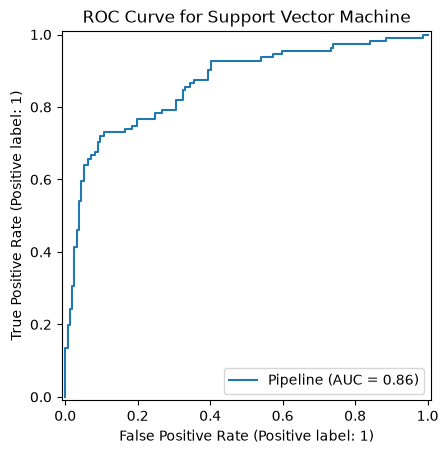

In [80]:
# ROC Curve for the best model
RocCurveDisplay.from_estimator(best_pipeline, X_test, y_test)
plt.title(f'ROC Curve for {best_model_name}')
plt.show()

# Feature importance

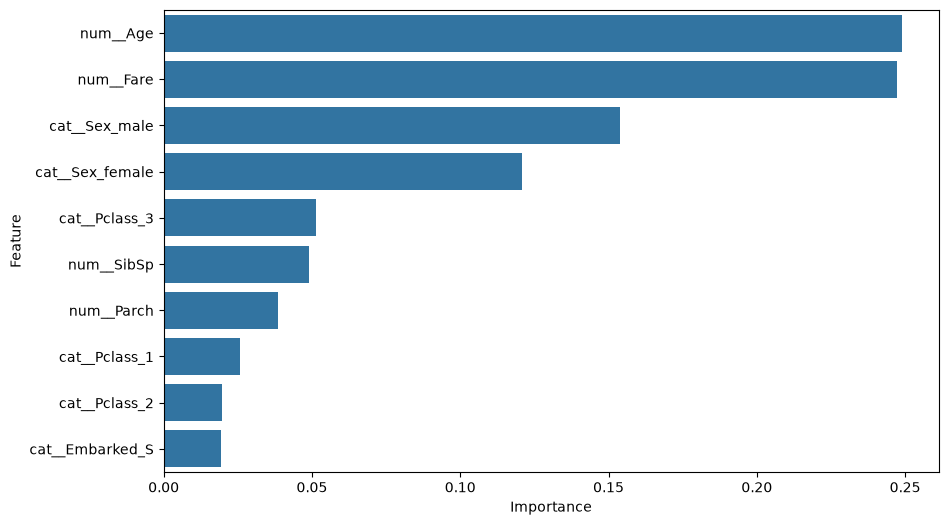

In [87]:
# Feature importance for random forest
# Pipeline for random forest
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))  
])

rf_pipeline.fit(X_train, y_train)

estimator = rf_pipeline.named_steps["classifier"]

feature_names = rf_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": estimator.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.show()

# Model Comparison

In [ ]:
| Algorithm           | Strengths                              | Weaknesses                                  |
| ------------------- | -------------------------------------- | ------------------------------------------- |
| Logistic Regression | Fast, interpretable                    | Linear decision boundary                    |
| KNN                 | Simple, intuitive                      | Sensitive to scaling and large datasets     |
| Decision Tree       | Easy to interpret                      | Prone to overfitting                        |
| Random Forest       | High accuracy, robust                  | Less interpretable                          |
| SVM                 | Effective in high-dimensional spaces   | Computationally expensive on large datasets |
| XGBoost             | Often state-of-the-art on tabular data | More hyperparameters to tune                |
